In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
)
import joblib

In [2]:
df = pd.read_csv("cyber security data.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 13)


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10000, 13)

Columns:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']

Missing Values:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [4]:
print("Label Counts:")
print(df["label"].value_counts())
print("\nLabel Percentage:")
print(df["label"].value_counts(normalize=True) * 100)

Label Counts:
label
0    9600
1     400
Name: count, dtype: int64

Label Percentage:
label
0    96.0
1     4.0
Name: proportion, dtype: float64


In [5]:
X_A = df.drop(columns=["label", "url", "attack_type"])
y_A = df["label"]
print("X_A Shape:", X_A.shape)
print("y_A Shape:", y_A.shape)
print("\nModel A Features:")
print(X_A.columns.tolist())

X_A Shape: (10000, 10)
y_A Shape: (10000,)

Model A Features:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'is_internal_traffic']


In [6]:
X_A["timestamp"] = pd.to_datetime(X_A["timestamp"])
print(X_A["timestamp"].head())
print("\nTimestamp datatype:")
print(X_A["timestamp"].dtype)

0   2025-10-01 00:12:54
1   2025-10-01 00:23:43
2   2025-10-01 00:25:46
3   2025-10-01 00:27:21
4   2025-10-01 00:40:09
Name: timestamp, dtype: datetime64[ns]

Timestamp datatype:
datetime64[ns]


In [7]:
X_A["hour"] = X_A["timestamp"].dt.hour
X_A["day_of_week"] = X_A["timestamp"].dt.dayofweek
X_A["month"] = X_A["timestamp"].dt.month
X_A = X_A.drop(columns=["timestamp"])
print("Features after timestamp processing:")
print(X_A.columns.tolist())

Features after timestamp processing:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'is_internal_traffic', 'hour', 'day_of_week', 'month']


In [8]:
X_A = X_A.drop(columns=["src_ip", "dst_ip"])
print("Final Model A Features:")
print(X_A.columns.tolist())
print("\nTotal Features:", len(X_A.columns))

Final Model A Features:
['src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'is_internal_traffic', 'hour', 'day_of_week', 'month']

Total Features: 10


In [9]:
print("Final X_A Shape:", X_A.shape)
print("Final y_A Shape:", y_A.shape)
print("\nMissing Values in X_A:")
print(X_A.isnull().sum())

Final X_A Shape: (10000, 10)
Final y_A Shape: (10000,)

Missing Values in X_A:
src_port               0
dst_port               0
protocol               0
bytes_sent             0
bytes_received         0
user_agent             0
is_internal_traffic    0
hour                   0
day_of_week            0
month                  0
dtype: int64


In [10]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y_A,
    test_size=0.20,
    random_state=42,
    stratify=y_A
)
print("Training Data:", X_train_A.shape)
print("Testing Data :", X_test_A.shape)
print("\nTraining Labels:")
print(y_train_A.value_counts())
print("\nTesting Labels:")
print(y_test_A.value_counts())

Training Data: (8000, 10)
Testing Data : (2000, 10)

Training Labels:
label
0    7680
1     320
Name: count, dtype: int64

Testing Labels:
label
0    1920
1      80
Name: count, dtype: int64


In [11]:
numeric_features_A = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "hour",
    "day_of_week",
    "month"
]

In [12]:
categorical_features_A = [
    "protocol",
    "user_agent",
    "is_internal_traffic"
]

In [13]:
numeric_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [14]:
categorical_pipeline_A = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [15]:
preprocessor_A = ColumnTransformer([
    ("numeric", numeric_pipeline_A, numeric_features_A),
    ("categorical", categorical_pipeline_A, categorical_features_A)
])

In [16]:
model_A = Pipeline([
    ("preprocessor", preprocessor_A),
    
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
print("Model A created successfully!")

Model A created successfully!


In [17]:
model_A.fit(X_train_A, y_train_A)
print("Model A training completed successfully!")

Model A training completed successfully!


In [18]:
y_pred_A = model_A.predict(X_test_A)
print("First 20 Predictions:")
print(y_pred_A[:20])

First 20 Predictions:
[0 1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1]


In [19]:
y_prob_A = model_A.predict_proba(X_test_A)[:, 1]
print("First 20 Attack Probabilities:")
print(y_prob_A[:20])

First 20 Attack Probabilities:
[0.26156978 0.88641431 0.18970807 0.2758327  0.53181733 0.45979851
 0.27561228 0.16449319 0.50638142 0.31841818 0.58736605 0.53193236
 0.52125597 0.19595038 0.36939487 0.37605836 0.25551203 0.57775861
 0.31314679 0.54405871]


In [20]:
accuracy_A = accuracy_score(y_test_A, y_pred_A)
print("Model A Accuracy:", accuracy_A)
print("Model A Accuracy (%):", accuracy_A * 100)

Model A Accuracy: 0.7175
Model A Accuracy (%): 71.75


In [21]:
precision_A = precision_score(y_test_A, y_pred_A)
recall_A = recall_score(y_test_A, y_pred_A)
f1_A = f1_score(y_test_A, y_pred_A)
print("Model A Performance")
print("-------------------")
print("Accuracy :", accuracy_A)
print("Precision:", precision_A)
print("Recall   :", recall_A)
print("F1 Score :", f1_A)

Model A Performance
-------------------
Accuracy : 0.7175
Precision: 0.09515859766277128
Recall   : 0.7125
F1 Score : 0.16789396170839468


In [22]:
roc_auc_A = roc_auc_score(y_test_A, y_prob_A)
print("Model A ROC-AUC:", roc_auc_A)

Model A ROC-AUC: 0.8118098958333334


In [23]:
print(classification_report(
    y_test_A,
    y_pred_A,
    target_names=["Benign", "Attack"]
))

              precision    recall  f1-score   support

      Benign       0.98      0.72      0.83      1920
      Attack       0.10      0.71      0.17        80

    accuracy                           0.72      2000
   macro avg       0.54      0.72      0.50      2000
weighted avg       0.95      0.72      0.80      2000



In [24]:
cm_A = confusion_matrix(y_test_A, y_pred_A)
print("Confusion Matrix:")
print(cm_A)

Confusion Matrix:
[[1378  542]
 [  23   57]]


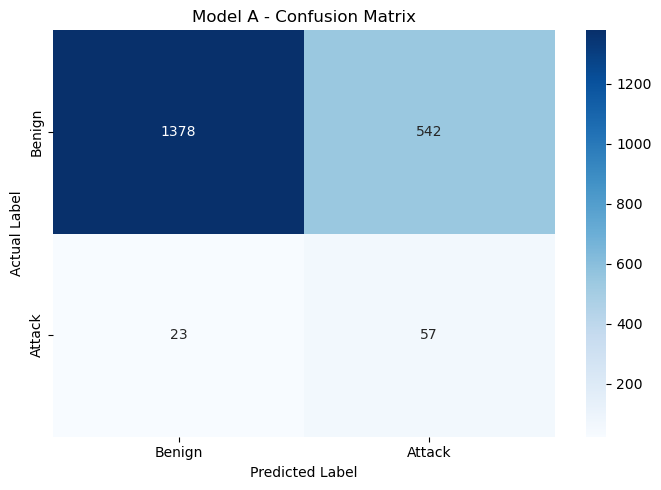

In [25]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_A,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.title("Model A - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "PNG FOLDER/model_A_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [26]:
model_A_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy_A,
        precision_A,
        recall_A,
        f1_A,
        roc_auc_A
    ]
})
model_A_results

,Metric,Score
0,Accuracy,0.717500
1,Precision,0.095159
2,Recall,0.712500
3,F1 Score,0.167894
4,ROC-AUC,0.811810


In [27]:
joblib.dump(model_A, "model_A.pkl")
print("Model A saved successfully as model_A.pkl")

Model A saved successfully as model_A.pkl


In [28]:
print("===================================")
print("          MODEL A SUMMARY")
print("===================================")

print("Dataset Rows       :", len(df))
print("Training Rows      :", len(X_train_A))
print("Testing Rows       :", len(X_test_A))

print("\nFeatures Used:")
for feature in X_A.columns:
    print("-", feature)

print("\nFeatures Removed:")
print("- label → Target")
print("- url → Not used")
print("- attack_type → Not used")
print("- src_ip → Dropped")
print("- dst_ip → Dropped")
print("- timestamp → Converted into time features")

print("\nPerformance:")
print("Accuracy  :", round(accuracy_A * 100, 2), "%")
print("Precision :", round(precision_A * 100, 2), "%")
print("Recall    :", round(recall_A * 100, 2), "%")
print("F1 Score  :", round(f1_A * 100, 2), "%")
print("ROC-AUC   :", round(roc_auc_A * 100, 2), "%")

print("\nModel A completed successfully!")

          MODEL A SUMMARY
Dataset Rows       : 10000
Training Rows      : 8000
Testing Rows       : 2000

Features Used:
- src_port
- dst_port
- protocol
- bytes_sent
- bytes_received
- user_agent
- is_internal_traffic
- hour
- day_of_week
- month

Features Removed:
- label → Target
- url → Not used
- attack_type → Not used
- src_ip → Dropped
- dst_ip → Dropped
- timestamp → Converted into time features

Performance:
Accuracy  : 71.75 %
Precision : 9.52 %
Recall    : 71.25 %
F1 Score  : 16.79 %
ROC-AUC   : 81.18 %

Model A completed successfully!
